# Jupyter and pandas Basics Demo

Keep `sample_data.csv` in the same folder as this notebook.

## 1. Jupyter Basics

This is a **Markdown cell**. Double-click to edit it, then run it to render.

- Use `#` for headings
- Use `**text**` for **bold**
- Use `-` for bullet points

In [1]:
# This is a code cell. Run it with Shift + Enter
print("Hello, Jupyter!")

Hello, Jupyter!


In [2]:
# Variables stay in memory after a cell runs
x = 10

In [3]:
# This cell depends on the cell above. Run that one first
x * 2

20

## 2. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Load Data

In [5]:
# Read a CSV file into a DataFrame
df = pd.read_csv("sample_data.csv")

In [6]:
# Optional: load JSON data from an API (placeholder URL, will not run)
# df = pd.read_json("https://my.pretend.api/data")

In [7]:
# Display the DataFrame
df

,ID,Category,Population
0,1,B,12000
1,2,C,8500
2,3,D,15200
3,4,A,12000
4,5,B,9800
5,6,C,11300
6,7,D,14100
7,8,A,7600
8,9,B,13400
9,10,C,10200


## 4. Basic Exploration

In [8]:
# First 5 rows
df.head()

,ID,Category,Population
0,1,B,12000
1,2,C,8500
2,3,D,15200
3,4,A,12000
4,5,B,9800


In [9]:
# (rows, columns)
df.shape

(20, 3)

In [10]:
# Column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          20 non-null     int64
 1   Category    20 non-null     str  
 2   Population  20 non-null     int64
dtypes: int64(2), str(1)
memory usage: 612.0 bytes


In [11]:
# Column names
df.columns

Index(['ID', 'Category', 'Population'], dtype='str')

In [12]:
# Select one column
df["Population"]

0     12000
1      8500
2     15200
3     12000
4      9800
5     11300
6     14100
7      7600
8     13400
9     10200
10    98000
11    12000
12     9100
13    16800
14    10700
15     8900
16    13900
17    11800
18    12600
19     1200
Name: Population, dtype: int64

## 5. Summary Statistics

In [13]:
# Store the column in a shorter name
col = df["Population"]

In [14]:
# Mean
col.mean()

np.float64(15455.0)

In [15]:
# Median
col.median()

np.float64(11900.0)

In [16]:
# Mode (returns a Series)
col.mode()

0    12000
Name: Population, dtype: int64

In [17]:
# Minimum
col.min()

np.int64(1200)

In [18]:
# Maximum
col.max()

np.int64(98000)

In [19]:
# Range
col.max() - col.min()

np.int64(96800)

In [20]:
# Variance
col.var()

np.float64(388286815.7894737)

In [21]:
# Standard deviation
col.std()

np.float64(19704.9946914348)

In [22]:
# First and third quartiles
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
print("Q1:", Q1)
print("Q3:", Q3)

Q1: 9625.0
Q3: 13525.0


In [23]:
# Interquartile range
IQR = Q3 - Q1
IQR

np.float64(3900.0)

In [24]:
# Summary of all numeric columns
df.describe()

,ID,Population
count,20.00000,20.000000
mean,10.50000,15455.000000
std,5.91608,19704.994691
min,1.00000,1200.000000
25%,5.75000,9625.000000
50%,10.50000,11900.000000
75%,15.25000,13525.000000
max,20.00000,98000.000000


## 6. Z-score

In [25]:
# Z-score of the first value
z = (df["Population"].iloc[0] - df["Population"].mean()) / df["Population"].std()
z

np.float64(-0.1753362563199162)

## 7. Outliers

In [26]:
# Outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 3775.0
Upper bound: 19375.0


In [27]:
# Rows outside the boundaries (| means "or")
outliers = df[
    (df["Population"] < lower_bound) |
    (df["Population"] > upper_bound)
]
outliers

,ID,Category,Population
10,11,D,98000
19,20,A,1200


## 8. Visualization

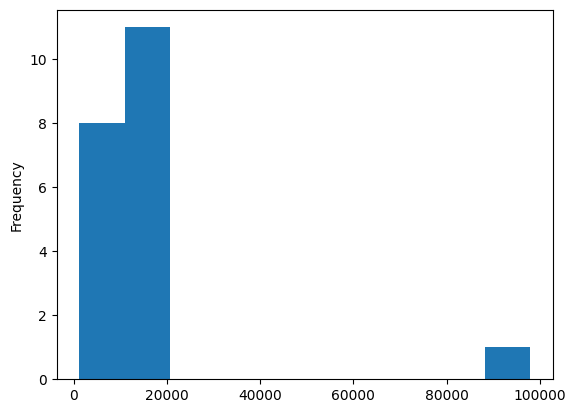

In [28]:
# Histogram
df["Population"].plot(kind="hist")
plt.show()